In [1]:
import os
import copy
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

In [2]:
IN_ROWS = 300
IN_COLS = 320
OUT_ROWS = 48
OUT_COLS = 48
NUM_CROPS = 5
DATA_DIR = f"/home/aelabd/RHEED/CoaxlinkOcto_1cam_2404/tb_data_Mono8/{IN_ROWS}x{IN_COLS}_to_{OUT_ROWS}x{OUT_COLS}x{NUM_CROPS}"
print(f"DATA_DIR: {DATA_DIR}\n")

TOTAL_BITS = 16
INT_BITS = 5

CROP_Y0_X0 = [(0,0), (0,30), (20,0), (40,40), (252, 272)]

DATA_DIR: /home/aelabd/RHEED/CoaxlinkOcto_1cam_2404/tb_data_Mono8/300x320_to_48x48x5



Helper functions

In [3]:
def ap_fixed_bin_to_float(bin_str: str, X: int, Y: int) -> np.float32:
    """
    Converts a binary string in two's complement ap_fixed<X,Y> format to a float.
    
    Parameters:
        bin_str (str): Binary string of length X.
        X (int): Total number of bits.
        Y (int): Number of integer bits (including sign bit).
        
    Returns:
        np.float32: Floating point value.
    """
    if len(bin_str) != X:
        raise ValueError(f"Binary string length ({len(bin_str)}) must match X ({X})")
    
    # Interpret binary string as signed integer
    int_val = int(bin_str, 2)
    if bin_str[0] == '1':  # Negative number (two's complement)
        int_val -= (1 << X)
    
    # Scale back by number of fractional bits
    frac_bits = X - Y
    value = int_val / (2 ** frac_bits)
    return np.float32(value)

def hex_to_float(hex_str, X: int, Y: int) -> np.float32:
    """
    Converts a hexadecimal string in two's complement ap_fixed<X,Y> format to a float.
    
    Parameters:
        hex_str (str): Hexadecimal 
        X (int): Total number of binary bits.
        Y (int): Number of integer bits (including sign bit).
        
    Returns:
        np.float32: Floating point value.
    """
    int_of_hex = int(hex_str, base=16)
    bin_str = bin(int_of_hex)
    bin_str = bin_str.split("b")[-1]
    if len(bin_str) < X:
        bin_str = "0"*(X-len(bin_str)) + bin_str
    elif len(bin_str) > X:
        raise NotImplementedError
    return ap_fixed_bin_to_float(bin_str, X, Y)

test1_bin = '00110100' # 3.25
test1_hex = "34" # 3.25
print("test1: from binary: ", ap_fixed_bin_to_float(test1_bin, 8, 4))  
print("test1: from hex: ", hex_to_float(test1_hex, 8, 4))

test2_bin = '11100000' # -2
test2_hex = "E0" # -2
print("\ntest2: from binary: ", ap_fixed_bin_to_float(test2_bin, 8, 4))  
print("test2: from hex: ", hex_to_float(test2_hex, 8, 4))


test1: from binary:  3.25
test1: from hex:  3.25

test2: from binary:  -2.0
test2: from hex:  -2.0


# Load QKeras output (benchmark)

In [4]:

qkeras_out_bin = []
qkeras_out = np.zeros((5, 5))
i = 0

for (y0,x0) in CROP_Y0_X0:
    if y0==0 and x0==13: continue
    fpath = os.path.join(DATA_DIR, f"Y1_{y0}_X1_{x0}/QKeras_mg1_pred_ap_fixed_{TOTAL_BITS}_{INT_BITS}.txt")
    print(f"fpath: {fpath}")
    qkeras_out_bin_y0_x0 = []
    with open(fpath, "r") as f:
        for j, line in enumerate(f.readlines()):
            qkeras_out_bin_y0_x0.append(line.replace("\n","").strip())
            line_float = ap_fixed_bin_to_float(line.strip(), TOTAL_BITS, INT_BITS)
            qkeras_out[i, j] = line_float
        i += 1
    
    qkeras_out_bin.append(qkeras_out_bin_y0_x0)

qkeras_out_bin = np.array(qkeras_out_bin)
print("\n", qkeras_out)
print("\n", qkeras_out_bin)

fpath: /home/aelabd/RHEED/CoaxlinkOcto_1cam_2404/tb_data_Mono8/300x320_to_48x48x5/Y1_0_X1_0/QKeras_mg1_pred_ap_fixed_16_5.txt
fpath: /home/aelabd/RHEED/CoaxlinkOcto_1cam_2404/tb_data_Mono8/300x320_to_48x48x5/Y1_0_X1_30/QKeras_mg1_pred_ap_fixed_16_5.txt
fpath: /home/aelabd/RHEED/CoaxlinkOcto_1cam_2404/tb_data_Mono8/300x320_to_48x48x5/Y1_20_X1_0/QKeras_mg1_pred_ap_fixed_16_5.txt
fpath: /home/aelabd/RHEED/CoaxlinkOcto_1cam_2404/tb_data_Mono8/300x320_to_48x48x5/Y1_40_X1_40/QKeras_mg1_pred_ap_fixed_16_5.txt
fpath: /home/aelabd/RHEED/CoaxlinkOcto_1cam_2404/tb_data_Mono8/300x320_to_48x48x5/Y1_252_X1_272/QKeras_mg1_pred_ap_fixed_16_5.txt

 [[0.39941406 0.58105469 0.72265625 0.50097656 0.02880859]
 [0.39355469 0.60644531 0.734375   0.49902344 0.02685547]
 [0.31835938 0.61376953 0.84277344 0.58789062 0.16748047]
 [0.52929688 0.44433594 0.79394531 0.57666016 0.07861328]
 [0.42431641 0.38525391 0.82470703 0.62451172 0.3203125 ]]

 [['0000001100110010' '0000010010100110' '0000010111001000'
  '00000

# Load input image

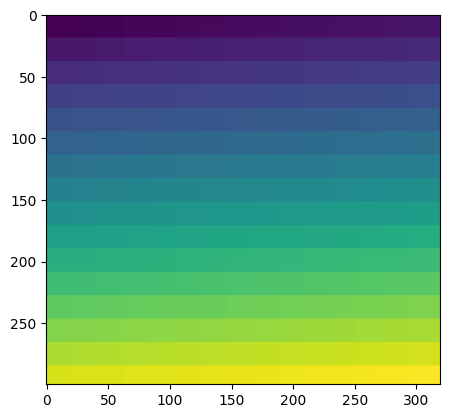

In [5]:
fpath_input = os.path.join(DATA_DIR, "img_precrop_Mono8_INDEX.dat")
img_in_hex = []

with open(fpath_input, "r") as f:
    lines = f.readlines()
    for l in lines:
        l_new = [i.replace("\n","") for i in l.split(" ")]
        l_new = [i for i in l_new if len(i)>0]
        img_in_hex.extend(l_new)

img_in_float = np.array([hex_to_float(i, 16, 5) for i in img_in_hex])
img_in_float = img_in_float.reshape((IN_ROWS,IN_COLS))
plt.imshow(img_in_float)

img_in_hex = np.array(img_in_hex).reshape((IN_ROWS, IN_COLS))
    

# Construct target RTL output

For NUM_CROPS crops, the data is hidden in the first NUM_CROPS pixels_bursts (each burst containing 16 pixels i.e. 128 bits at 8 bits/pixel). In particular, the first 80 bits of the burst (i.e. the first 10 pixels) should match exactly with the 80-bit RTL output.

In [6]:
img_out_target_hex = copy.deepcopy(img_in_hex)
pixel_overlaid_indeces = [range(0,10), range(16,26), range(32,42), range(48,58), range(64,74)]

def bin_to_hex(bin_str):
    int_of_bin = int(bin_str,2)
    hex_of_bin = hex(int_of_bin).replace("0x","")
    if len(hex_of_bin)<2:
        hex_of_bin = "0"*(2-len(hex_of_bin)) + hex_of_bin
    return hex_of_bin

for crop_idx in range(NUM_CROPS):
    pixel_indeces = pixel_overlaid_indeces[crop_idx]
    for param_idx in range(5):
        data_bin = qkeras_out_bin[crop_idx, param_idx]

        data_bin_0 = data_bin[8:]
        data_bin_1 = data_bin[:8]
        # print(f"\ndata_bin_0: {data_bin_0}, data_bin_1: {data_bin_1}")

        data_hex_0 = bin_to_hex(data_bin_0)
        data_hex_1 = bin_to_hex(data_bin_1)
        print(f"data_hex_0: {data_hex_0}, data_hex_1: {data_hex_1}")

        pixel_0_idx = pixel_indeces[param_idx*2]
        pixel_1_idx = pixel_indeces[param_idx*2+1]

        img_out_target_hex[0, pixel_0_idx] = data_hex_0
        img_out_target_hex[0, pixel_1_idx] = data_hex_1

# img_out_target_hex[0,:]

data_hex_0: 32, data_hex_1: 03
data_hex_0: a6, data_hex_1: 04
data_hex_0: c8, data_hex_1: 05
data_hex_0: 02, data_hex_1: 04
data_hex_0: 3b, data_hex_1: 00
data_hex_0: 26, data_hex_1: 03
data_hex_0: da, data_hex_1: 04
data_hex_0: e0, data_hex_1: 05
data_hex_0: fe, data_hex_1: 03
data_hex_0: 37, data_hex_1: 00
data_hex_0: 8c, data_hex_1: 02
data_hex_0: e9, data_hex_1: 04
data_hex_0: be, data_hex_1: 06
data_hex_0: b4, data_hex_1: 04
data_hex_0: 57, data_hex_1: 01
data_hex_0: 3c, data_hex_1: 04
data_hex_0: 8e, data_hex_1: 03
data_hex_0: 5a, data_hex_1: 06
data_hex_0: 9d, data_hex_1: 04
data_hex_0: a1, data_hex_1: 00
data_hex_0: 65, data_hex_1: 03
data_hex_0: 15, data_hex_1: 03
data_hex_0: 99, data_hex_1: 06
data_hex_0: ff, data_hex_1: 04
data_hex_0: 90, data_hex_1: 02


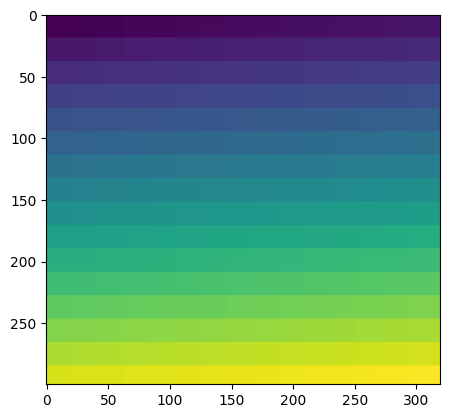

In [7]:
img_out_target_float = np.array([[hex_to_float(i, 16, 5) for i in row] for row in img_out_target_hex])
plt.imshow(img_out_target_float)
# img_out_target_float[0,:]

# Load 07_vivado_project/CustomLogic.sim/*.dat files
These contain the RTL output that is: the input image, but with the first few pixels replaced with the CNN output

In [8]:
# dat_dir = f"/home/aelabd/RHEED/CoaxlinkOcto_1cam_2404/07_vivado_project/CustomLogic.sim/sim_1/behav/xsim"
# dat_files = [i for i in os.listdir(dat_dir) if i.endswith(".dat")]
# for f in dat_files: os.remove(os.path.join(dat_dir, f))

In [9]:
def get_dat_num(fname):
    return fname.split(".dat")[0][-3:]

dat_dir = f"/home/aelabd/RHEED/CoaxlinkOcto_1cam_2404/07_vivado_project/CustomLogic.sim/sim_1/behav/xsim"
dat_files = [i for i in os.listdir(dat_dir) if i.endswith(".dat") and "memento" not in i]
dat_files = sorted(dat_files, key = lambda x: get_dat_num(x), reverse=True)

# Find which file the last image output starts from
last_img_start_idx = None
last_img_start_fpath = None
for fpath_idx, fpath in enumerate(dat_files):
    with open(os.path.join(dat_dir, fpath), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "PAYLOAD" in line:
                last_img_start_idx = fpath_idx
                last_img_start_fpath = fpath
    
    if last_img_start_idx is not None: break

last_img_fpaths = dat_files[:last_img_start_idx+1]
last_img_fpaths.reverse()

In [10]:
last_img_fpaths[0]

'cl_output_data_ch0_001.dat'

In [11]:
img_out = []
with open(os.path.join(dat_dir, last_img_fpaths[0]), "r") as f:
    lines = f.readlines()
    start_idx = None
    for idx_l, l in enumerate(lines): 
        if "PAYLOAD" in l:
            start_idx = idx_l+1
            break

    lines = lines[start_idx:]
    for l in lines: img_out.extend(l.split(" "))

img_out = [i.replace("\n","") for i in img_out]
img_out = [i for i in img_out if len(i)>0]

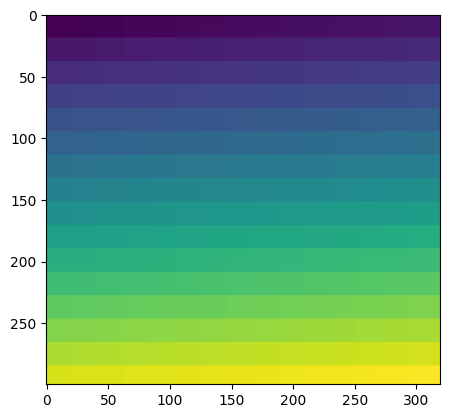

In [12]:
img_out_float = np.array([hex_to_float(i, 16, 5) for i in img_out])
img_out_float = img_out_float.reshape((IN_ROWS,IN_COLS))
plt.imshow(img_out_float, vmin=0, vmax=np.max(np.max(img_out_float, axis=0), axis=0))

Confirm write-time of output

In [13]:
!ls -l /home/aelabd/RHEED/CoaxlinkOcto_1cam_2404/07_vivado_project/CustomLogic.sim/sim_1/behav/xsim

total 20712
-rw-r--r-- 1 aelabd aelabd   288359 Oct  9 17:04 cl_output_data_ch0_000.dat
-rw-r--r-- 1 aelabd aelabd   288359 Oct  9 17:06 cl_output_data_ch0_001.dat
-rw-r--r-- 1 aelabd aelabd       66 Oct  9 17:04 cl_output_memento.dat
-rw-r--r-- 1 aelabd aelabd     2670 Oct  9 17:03 compile.log
-rwxr-xr-x 1 aelabd aelabd      956 Oct  9 17:03 compile.sh
-rw-r--r-- 1 aelabd aelabd     1300 Oct  9 17:03 CustomLogic.smi
-rw-r--r-- 1 aelabd aelabd    29542 Oct  9 17:04 elaborate.log
-rwxr-xr-x 1 aelabd aelabd     2498 Oct  9 17:03 elaborate.sh
-rw-r--r-- 1 aelabd aelabd     1762 Oct 13  2022 glbl.v
-rw-r--r-- 1 aelabd aelabd    24673 Oct  9 17:04 simulate.log
-rwxr-xr-x 1 aelabd aelabd      946 Oct  9 17:04 simulate.sh
-rw-r--r-- 1 aelabd aelabd 20355456 Oct  9 17:06 tb_top_behav.wdb
-rw-r--r-- 1 aelabd aelabd      450 Oct  9 17:04 tb_top.tcl
-rw-r--r-- 1 aelabd aelabd     2205 Oct  9 17:03 tb_top_vhdl.prj
-rw-r--r-- 1 aelabd aelabd    30403 Oct  9 17:03 tb_top_vlog.prj
-rw-r--r-- 1 aelabd

# Extract predicted parameters from img_out_float

In [14]:
img_diff = img_out_float-img_out_target_float
for i in range(IN_ROWS):
    if i>0: assert(np.allclose(img_out_target_float[i,:], img_out_float[i,:]))

In [20]:
img_diff[0][:80]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [15]:
img_out_float[0][:80]

array([0.02441406, 0.00146484, 0.08105469, 0.00195312, 0.09765625,
       0.00244141, 0.00097656, 0.00195312, 0.02880859, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.01855469, 0.00146484, 0.10644531, 0.00195312,
       0.109375  , 0.00244141, 0.12402344, 0.00146484, 0.02685547,
       0.        , 0.00048828, 0.00048828, 0.00048828, 0.00048828,
       0.00048828, 0.00048828, 0.06835938, 0.00097656, 0.11376953,
       0.00195312, 0.09277344, 0.00292969, 0.08789062, 0.00195312,
       0.04248047, 0.00048828, 0.00097656, 0.00097656, 0.00097656,
       0.00097656, 0.00097656, 0.00097656, 0.02929688, 0.00195312,
       0.06933594, 0.00146484, 0.04394531, 0.00292969, 0.07666016,
       0.00195312, 0.07861328, 0.        , 0.00097656, 0.00097656,
       0.00097656, 0.00097656, 0.00097656, 0.00146484, 0.04931641,
       0.00146484, 0.01025391, 0.00146484, 0.07470703, 0.00292969,
       0.12451172, 0.00195312, 0.0703125 , 0.00097656, 0.00146

In [16]:
img_out_target_float[0][:80]

array([0.02441406, 0.00146484, 0.08105469, 0.00195312, 0.09765625,
       0.00244141, 0.00097656, 0.00195312, 0.02880859, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.01855469, 0.00146484, 0.10644531, 0.00195312,
       0.109375  , 0.00244141, 0.12402344, 0.00146484, 0.02685547,
       0.        , 0.00048828, 0.00048828, 0.00048828, 0.00048828,
       0.00048828, 0.00048828, 0.06835938, 0.00097656, 0.11376953,
       0.00195312, 0.09277344, 0.00292969, 0.08789062, 0.00195312,
       0.04248047, 0.00048828, 0.00097656, 0.00097656, 0.00097656,
       0.00097656, 0.00097656, 0.00097656, 0.02929688, 0.00195312,
       0.06933594, 0.00146484, 0.04394531, 0.00292969, 0.07666016,
       0.00195312, 0.07861328, 0.        , 0.00097656, 0.00097656,
       0.00097656, 0.00097656, 0.00097656, 0.00146484, 0.04931641,
       0.00146484, 0.01025391, 0.00146484, 0.07470703, 0.00292969,
       0.12451172, 0.00195312, 0.0703125 , 0.00097656, 0.00146

For 5 crops, the first 5 bursts (of 16 pixels each) will have the last 80 bits (i.e. the last 10 pixels, at 8 bits/pixel) replaced with the inference parameters.

This means pixels: 6->15, 22->31, 38->47, 54->63, 70->79

In [17]:
overlaid_pixel_indeces = list(range(6, 16)) + list(range(22, 32)) + list(range(38, 48)) + list(range(54, 64)) + list(range(70, 80))
overlaid_pixels = img_out_float[overlaid_pixel_indeces]

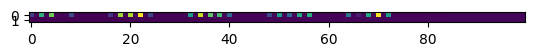

In [18]:
plt.imshow(img_out_float[:2, :100])

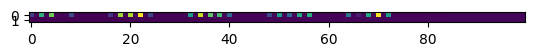

In [19]:
plt.imshow(img_out_target_float[:2, :100])

In [34]:
np.array(img_out).reshape((IN_ROWS,IN_COLS))[0,:100]

array(['32', '03', 'A6', '04', 'C8', '05', '02', '04', '3B', '00', '00',
       '00', '00', '00', '00', '00', '26', '03', 'DA', '04', 'E0', '05',
       'FE', '03', '37', '00', '01', '01', '01', '01', '01', '01', '8C',
       '02', 'E9', '04', 'BE', '06', 'B4', '04', '57', '01', '02', '02',
       '02', '02', '02', '02', '3C', '04', '8E', '03', '5A', '06', '9D',
       '04', 'A1', '00', '02', '02', '02', '02', '02', '03', '65', '03',
       '15', '03', '99', '06', 'FF', '04', '90', '02', '03', '03', '03',
       '03', '03', '03', '03', '03', '03', '03', '04', '04', '04', '04',
       '04', '04', '04', '04', '04', '04', '04', '04', '04', '04', '04',
       '04'], dtype='<U2')

In [35]:
qkeras_out

array([[0.39941406, 0.58105469, 0.72265625, 0.50097656, 0.02880859],
       [0.39355469, 0.60644531, 0.734375  , 0.49902344, 0.02685547],
       [0.31835938, 0.61376953, 0.84277344, 0.58789062, 0.16748047],
       [0.52929688, 0.44433594, 0.79394531, 0.57666016, 0.07861328],
       [0.42431641, 0.38525391, 0.82470703, 0.62451172, 0.3203125 ]])